<h1 style="text-align: center;">ANÁLISIS Y PROCESAMIENTO DE SEÑALES</h1>

<center>
    
### 1er cuatrimestre 2026
</center>

<p style="text-align: center;">Muñoz Jazmín Ayelén</p>

<h3 style="text-align;">INTRODUCCIÓN</h3>

El Electrocardiograma **(ECG)** es un registro de la actividad eléctrica del corazón, el cual se mide mediante electrodos desde la superficie cutánea. Es una señal de amplitudes muy pequeñas, del orden de **1 a 5 mV** esto conlleva a que sea sumamente vulnerable a interferencias externas, sobretodo durante una prueba de esfuerzo, conocida como ergometría, donde el paciente se encuentra en constante movimiento, ya sea en una bicicleta fija o caminando sobre una cinta. 

En esta tarea semanal número siete, se tratará de mitigar tres fuentes específicas de ruido:

**1. Ruido causado por el movimiento de los electrodos (Alta frecuencia):**

Teniendo en cuenta lo mencionado anteriormente, respecto a la prueba de ergometría, cada pisada fuerte en la cinta podría producir un movimiento -tirón- en los cables del electrodo, perturbando de manera mecánica la doble capa electroquímica de la dermis. 

En la superficie exterior de la piel, existe una diferencia de potencial denominada "Potencial de protección de la piel" este tironeo, que a diferencia de la respiración cuyo carácter es conocido por ser suave y cíclico,  genera cambios de potencial transistorios que son rápidos e impredecibles, pudiendo inyacterse en el detector como pulsos o picos agudos. 

Estos pueden simular en el registro, la actividad eléctrica cardíaca real. Cuando el especialista analiza el registro, puede encontrarse con patologías clínicas, como un latido anormal originado en los ventrículos, taquicardia ventricular, siendo esta una arritmia potencialmente mortal, entre otras. 

El doctor podría entonces. generar una alarma en el paciente basado en un error mecánico del cable.

**2. Ruido muscular o Electromiográfico (EMG) (Alta Frecuencia):**

El corazón no es el único órgano perteneciente al torso que posee un carácter eléctrico, para que el paciente pueda correr o pedalear en la ergometría, los grandes grupos musculares, como dorsales, intercostales y pectorales deben contaerse sostenidamente. Para que surja dicha contracción, deben activarse miles de unidades motoras que disparan potenciales de acción de forma aleatorio, este se comporta como un ruido blanco que se superpone a partir de los $35\text{ Hz}$. 

Este ruido produce una "pelusa" que deforma las transiciones rápidas de la señal, enmascarando la onda P de la despolarización auricular, la onda T de la repolarización verntricular. Además, puede también alterar al complejo QRS.

**3. Movimiento de la línea de base del ECG, inducido en parte por la respiración (Baja frecuencia):**

La interfaz que conecta la piel con el electrodo no es un simple cable conductor, sino que consiste en un transductor electroquímico, hay un gel conductor que interactúa con los iones de la piel, lo que genera un potencial, una pequeña tensión continua de DC, denominado **"Potencial de media celda"**.
Cuando el paciente respira, el tórax se espande y se contrae, estirndo la piel bajo el electrodo y alterando por ende, el espesor de la capa de gel. Esto provoca que el potencial de media celda mencionado varíe dinámicamente al ritmo de la respiración. 

Además, si el pacien transpira producto del esfuerzo, el sudor lleno de iones alterará la concentraciónq uímica de la interfaz, lo que cambiará la impedancia, produciendo una variación lenta e indeseada, - deriva.

La **deriva** o drift, es una variación de muy baja frecuencia que desplaza el nivel de referencia de una señal. En este caso se debería producir un desplazamiento vertical de todo el trazo de la señal en el dominio del tiempo, o sea que a los valores de tensión - amplitud - medidos por el electrodo se les sumará un valor que varía lentamente.

Esto produce el la destrucción del nivel isoeléctrico, el segmento ST y PR que se usan como referencia de potencial cero, se mueve y resulta imposible medir precisamente si el segmento ST está por debajo o por encima. 

Como consecuencia, se puede producir un diagnóstico crítico simulando una patología inexistente, tal como una isquemia miocárdica o un infarto agudo, o por el contrario, pasar por alto patologías preexistentes. 


Con esto en mente, es el objetivo de esta tarea semanal, y de la ingeniería en sí , diseñar filtros pasa - banda digitales con el propósito de que la señal que se procesa, se asemeje a los latidos promedios del corazón.  Eliminando el ruido de alta frecuencia y logrando un nivel isoeléctrico nuelo mediante la supresión de la deriva de baja frecuencia. 

<h4 style="text-align;">Forma del ECG</h4>

![Captura de pantalla de la forma de el  ECG.](morfologiacardio.jpg)

Para comprender mejor el fenómeno que se está analizando, cabe mencionar que la señal electrocardiográfica es el registro eléctrico de la actividad del corazón. Un latido se compone de tres eventos fisiológicos:

**1) Onda P:** Esta parte representa la despolarización, se da una contracción de las aurículas.Suele ser una onda suave y de baja amplitud, por lo tanto su contenido espectral se ubica en las frecuencias bajas. 

**2) Complejo QRS:** Respreseta la despolarización de los ventrículos, esto genera un pulso filoso con gran amplitud ya que los ventrículos son músculos más grandes y rápidos.  En este complejo se concentra la mayor parte de enerfía de alta frecuencia. 

**3) Onda T:** Esta prte es la repolarización centricular, su relajación para el siguiente latido. Es una onda ancha. 

**4) Segmento PR y ST:** Es el nivel isoeléctro entre las ondas, siendo el ST de suma importancia clínica puesto que cualquier desnivel respecto al mismo es un indicador de isquemia o infarto. 


<h4 style="text-align;">Definición Teórica de la Plantilla de Diseño</h4>

Para tratar de aislar la señal del ECG de las interferencias ambientales y fisiológicas, buscando preservar su infomación médica, es necesario establecer el ya mencioando "trade off" o compromiso. Para ello es necesario equilibrar lo esperado en base al estándar clínico y las características reales de los componentes de la señal que se obtuvieron de forma experimental.

**A) Estándar Clínico Internacional frente a pruebas de esfuerzo:** 

La American Heart Association (AHA) y la Comisión Electrotécnica Internacional (IEC) establece que para un ECG durante una prueba ergométrica, se recomienda achicar el ancho de banda clínico a un rango de $0.5\text{ Hz} - 40\text{ Hz}$ para mitigar interferencias previas a la etapa de detección.

**B) Parámetros del ancho de banda calculado en la TS5:**


![Captura de pantall de los resultados de la Ts anrterior.](anchobandaecg.jpg)

De la tarea semanal número cinco, se obtuvo que el ancho de banda del ECG se encuentra entre los $26\text{ Hz}$ - $33\text{ Hz}$ , el ancho de banda permite garantizar que al menos el 99% de la energía útil de la señal se encuentra contenido ahí, entonces se podría decir que el otro 1% de la energía, resulta prácticamente despreciable. 

Para el diseño de una plantilla de filtros, el ancho de banda es de suma importancia, pues permite fijar el fin de la banda de paso superior ($w_{p2}$). Debido a que los filtros reales no poseen una transición ideal abrupta, como ya se ha conversado tanto en clase como en otras tareas semanales anteriores, fijar la frecuencia de corte en  $33\text{ Hz}$ podría provocar que la pendiente de caida del filtro, comience a atenuar armónicos de la señal que en realidad deseamos conservar, por ello es necesario establecer un marfen de seguridad fijando  $w_{p2}$ en por ejemplo, $35\text{ Hz}$ , esto garantiza la preservación de la forma de la señal a su vez que incorpora la menor cantidad posible de ruido externo. 

**Establecimiento de los Vértices de la Plantilla de Tolerancia.**

**ACLARACIÓN:**  Le pedí a la inteligencia artificial que me hiciera la siguiente imagen, donde manualmente le agregué cada referencia a los índices de frecuencias de interés, usnaod como base el gráfico que figura en el Campus, en las consignas de la tarea presente. 

Esto con el fin de entender mejor qué es lo que se está realizando y que sirva como herramienta visual para lograr una mejor comprensión de cada zona de interés como así también de la importancia de la correcta elección de las  $\text{w}$ y del porqué hago lo que hago , para luego poder volver a releer las TS y que sirva a modo de guía para el estudio de la materia. 


![Captura de pantall de los resultados de la Ts anrterior.](plantilla.jpg)

En base a lo charlado durante la clase y a la explicación del profesor Mariano para los parámetros del diseño del filtro en el marco del análisis de una señal de ECG bajo una prueba de ergometría, se definen a continuación los límites frecuenciales para el diseño de dicho filtro pasa-banda digital:

**1) Banda de rechazo inferior:**
$$w_{s1} = 0.05\text{ Hz}$$ 



La $w_{s1}$ = $0.05\text{ Hz}$ permite bloquear la corriente continua (DC) y los movimientos lentos,  es la "pared de rechazo inferior", cualquier fenómeno físico que oscile a $0.05\text{ Hz}$ o más lento, va a s er  "planchado" con al menos $40\text{ dB}$ de atenuación. El objetivo de esta restricción consiste en mitigar el ruido que se introduce cuando el paciente respira o transpira, debido a que como ya se mencionó antes, estos eventos alteran la impedancia de la faz electrodo-gel y su potencial de **media celda** generando una tensión parasitaria a baja frecuencia que provococa la deriva. Cuando se fija el rechazo en $0.05\text{ Hz}$ se logra suprimir dicha deriva.

En un principio el profesor había sugerido que sea $w_{s1} = 0.1\text{ Hz}$ , luego se modificó a $w_{s1} = 0.05\text{ Hz}$ ya que el valor anterior era insuficiente para lograr la respuesta esperada.

**2) Inicio de la banda de paso:** 
$$w_{p1} = 1.0\text{ Hz}$$

Marca donde termina la zona de transición e inicia la zona de ganancia ideal ($0\text{ dB}$), es decir que a partir de $1\text{ Hz}$, deja pasar la señal intacta, ya que las ondas P y T de la repolarización de los ventrículos son fenómenos de baja frecuencia, si se corre este punto muy arriba, el filtro  empieza a comportarse como un derivador, inclinando las líneas horizontales, lo que curva el segmento ST pudiendo provocar que un médico diagnostique una isquemia , infarto , falsa.

*En toda esta primera instancia se puede observar el comportamiento de un filtro de tipo pasa - alto, del pasa-banda.*

**3) Fin de la banda de paso:**
$$w_{p2} = 35.0\text{ Hz}$$

Es el final de la banda de paso , hasta los $35\text{ Hz}$ se mantiene la señal totalmente sin atenuar, ya que el 99% de la energía de la señal, se concentra  alrededor de los $32\text{ Hz}$ , sin embargo como también ya se mencionó previamente, este valro se estira hasta los $35\text{ Hz}$ para dar un margen de seguridad con el cuidado de no recortar información perteneciente a los armónicos de la onda que se desean preservar. 

**4) Inicio de la banda de rechazo con $-40\text{ dB}$:**
$$w_{s2} = 50.0\text{ Hz}$$

La zona que transcurre entre los $35\text{ Hz}$ y $50\text{ Hz}$ será la banda o zona de transición nuevamente, la cual le da espacio al filtro para que caiga. Cuando llega a los $50\text{ Hz}$ se exige la máxima atenuación, pues ya no hay nada que se desee preservar, solo ruido muscular y de la línea de red eléctrica. 

*En toda esta segunda instancia se puede observar el comportamiento de un filtro de tipo pasa - bajoo, del pasa-banda.*

<h3 style="text-align;">CONSIGNAS</h3>

a) Establezca una plantilla de diseño para los filtros digitales que necesitará para que la señal de ECG se asemeje a los latidos promedio en cuanto a  suavidad de los trazos y nivel isoeléctrico nulo.

Ayuda: Utilice los resultados del ancho de banda estimado del ECG en la Tarea Semanal 5. Tome como referencia las siguientes morfologías promedio para evaluar cualitativamente la efectividad de los filtros diseñados.


b) ¿Cómo obtuvo dichos valores? Describa el procedimiento para establecer los valores de la plantilla.

Esta parte se resolvió en la introducción pero a modo de resumen, detallo los valores elegidos. 
**Frecuencias límites seleccionadas a partir del análisis espectral de la TS5:**
- ws1 = 0.05           # Banda de rechazo inferior (Hz)
- wp1 = 1.0            # Banda de paso inferior (Hz)
- wp2 = 35.0           # Banda de paso superior (Hz)
- ws2 = 50.0           # Banda de rechazo superior (Hz)

**ACLARACIÓN:** Esta parte la rehice porque me quedaba muy mal los FIR de Remez y de cuadrados mínimos y como yo falté una clase, el profesor me explicó que debía elaborar un proc

c) Diseñe al menos dos filtros FIR y dos IIR para su comparación. Verifique que la respuesta en frecuencia responda a la plantilla de diseño.

Ayuda: Para los filtros IIR adopte las aproximaciones de módulo de máxima planicidad, Chebyshev y Cauer. Para los FIR, utilice las metodologías de ventanas, cuadrados mínimos y Parks-Mc Clellan-Remez. Todos implementados en SciPy.Signal

d)  Evalúe el rendimiento de los filtros que haya diseñado:

1. Verifique que filtra las señales interferentes.
2. Verifique que es inocuo en las zonas donde no hay interferentes.


Ayuda: Utilice el código como referencia para analizar los puntos 1 y 2). También puede incluir otras regiones que considere de interés.



<h4 style="text-align;">DEFINO LOS PROXYS O PLANTILLAS PARA CADA FILTO</h4>

**FILTROS DE RESPUESTA FINITA AL IMPULSO** 

En principio, para los filtros de respuesta al impulso finita, se utilizarán *Firwin* , *Firls* y *remez*

**1. FIRWIN - DISEÑO POR VENTANEO** 

Se usará la función: *scipy.signal.firwin* 

Este método parte de la respuesta de un filtro ideal, el cual en el dominio del tiempo, es una función Sinc con longitud infinita. Al no poder procesar una señal infinita, se corta - trunca- dicha  Sinc multiplicándola por una ventana de longitud finita.

Según la forma geométrica de la ventana, ya sea rectangular, Hamming, Hann, Blackman o cualquier otra, el corte será más brusco o más suave. Esto determina el ancho de la transición y la atenuación del ruido, es decir inferirá en los lóbulos secundarios.

Los parámetros que pide la función se detallan a continuación: 

- numtaps: El número de coeficientes del filtro, es el orden + 1. Si es impar.

- cutoff: La frecuencia o frecuencias, donde se desea que el filtro corte.

- window: El tipo de ventana que se va a utilizar, si no se especifica, asume Hamming por defecto.

- pass_zero: Es un booleano, del tipo true o false,  define si el filtro deja pasar la frecuencia cero, es decir la corriente continua.
Es útil si se quiere realizar un pasabanda pues, si se tiene dos cortes y pass_zero=False, el algoritmo entiende que es un Pasa-Banda debido a quecorta abajo (La DC) y corta arriba (las altas frecuencias).

- fs: La frecuencia de muestreo.

In [109]:
def proxy_firwin(numtaps_global, frecs, fs):
    ws1, wp1, wp2, ws2 = frecs
    return sig.firwin(numtaps_global, [wp1, wp2], pass_zero=False, window='hamming', fs=fs)#Pongo pass_zero false porque quiero un pasabanda. 

**2. FIRLS - CUADRADOS MÍNIMOS.** 

Se usará la función: *scipy.signal.firls*  

Es un método de optimización analítica, en lugar de truncar una función a la fuerza con una ventana, este algoritmo calcula los coeficientes resolviendo un gran sistema de ecuaciones, matrices, con el fin de minimizar la energía total del error, la integral del error elevada al cuadrado, entre la respuesta real y la plantilla.

Los parámetros que pide la función se detallan nuevamente a continuación: 

- numtaps.
- bands: Una lista plana con los bordes exactos de todas las bandas.
Para un pasa-banda sería: [0, inicio_stop, inicio_pass, fin_pass, inicio_stop2, Nyquist].
- desired: La ganancia exacta punto a punto correspondiente a cada frecuencia del vector bands. La cantidad debe coincidir con la de bands.
- fs: La frecuencia de muestreo.

In [110]:
def proxy_firls(numtaps_global, frecs, fs):
    ws1, wp1, wp2, ws2 = frecs
    
    # Acá probé varios valores, llegando hasta más de 2000 tal como en clase, pero cuando los ponía todos juntos se rompía, fui probando diferentes
    #valores por mucho tiempo hasta que este no me lo rompió, al final hago un análisis de esto. 
    numtaps_aislado = 201 
    
    nyq = fs / 2.0
    bands = [0, ws1, wp1, wp2, ws2, nyq]
    desired = [0, 0, 1, 1, 0, 0]
    
    return sig.firls(numtaps_aislado, bands, desired, fs=fs)

**3. REMEZ - PARKS - MCCLELLAN.** 

Se usará la función: *scipy.signal.remez*

Este método utiliza un algoritmo iterativo, llamado optimización Minimax que como su nombr indica sirve para minimizar el error máximo absoluto. 
En lugar de tener en cuenta la energía total del error, se asegura de que el pico de error más alto sea lo más bajo posible.
El resultado matemático de esto es un filtro equiripple, donde las oscilaciones en la banda de paso y de rechazo tienen siempre exactamente la misma amplitud. Es por ello que garantiza el filtro de menor orden posible para cumplir una plantilla estricta, sin embargo, ignora lo que pasa en la banda de transición, lo que puede generar anomalías si se le exigen cortes muy abruptos con pocos coeficientes.

- numtaps.
- bands.
- desired:  A diferencia de firls, pide la ganancia por banda, no en los puntos. 
- fs: La frecuencia de muestreo.


In [111]:
def proxy_remez(numtaps_global, frecs, fs):
    ws1, wp1, wp2, ws2 = frecs
    nyq = fs / 2.0
    numtaps_aislado = 201 
    bands = [0, ws1, wp1, wp2, ws2, nyq]
    desired = [0, 1, 0]
    
    return sig.remez(numtaps_aislado, bands, desired, weight=[10, 1, 10], fs=fs)

**4. FILTRO TIPO 3**

Aclaración: Agregué esto medio a último momento porque me lo propuso Mariano en clase. Así que creé oootra plantilla para este.

In [112]:
def proxy_fir_tipo3(numtaps_global, frecs, fs):
    ws1, wp1, wp2, ws2 = frecs
    nyq = fs / 2.0
    
    # Pars que sea de Tipo 3, tengo que forzr  taps impar y una antisimetría que lo hago en la parte antisymmetric=True. 
    numtaps_aislado = 501
    bands = [0, ws1, wp1, wp2, ws2, nyq]
    desired = [0, 0, 1, 1, 0, 0]
    return sig.firwin2(numtaps_aislado, bands, desired, antisymmetric=True, window='hamming', fs=fs)

**FILTROS DE RESPUESTA INFINITA AL IMPULSO.** 

La consigna pide utilizar el de máxima planicidad, o sea el de Butterworth, Chebyshev, usaré el de tipo I y tipo II, además del elíptico de Cauer. 

Todos implementados bajo SOS.

**Importo los las librerías y cargo el archivo del ECG.**

In [113]:
import numpy as np
import matplotlib.pyplot as plt
import scipy.signal as sig
import scipy.io as sio

mat_data = sio.loadmat('./ecg.mat')
ecg_one_lead = mat_data['ecg_lead'].flatten() #Dijo Mariano que acá use flatten para asegurar la dimensión. 
cant_muestras = len(ecg_one_lead)

In [114]:
#VUELVO A PEGAR LOS PROXYS PARA TENERLOS TODOS JUNTITOS. 

def proxy_firwin(numtaps_global, frecs, fs):
    ws1, wp1, wp2, ws2 = frecs
    return sig.firwin(numtaps_global, [wp1, wp2], pass_zero=False, window='hamming', fs=fs)#Pongo pass_zero false porque quiero un pasabanda. 
    
def proxy_firls(numtaps_global, frecs, fs):
    ws1, wp1, wp2, ws2 = frecs
    
    # Acá probé varios valores, llegando hasta más de 2000 tal como en clase, pero cuando los ponía todos juntos se rompía, fui probando diferentes
    #valores por mucho tiempo hasta que este no me lo rompió, al final hago un análisis de esto. 
    numtaps_aislado = 201 
    
    nyq = fs / 2.0
    bands = [0, ws1, wp1, wp2, ws2, nyq]
    desired = [0, 0, 1, 1, 0, 0]
    
    return sig.firls(numtaps_aislado, bands, desired, fs=fs)
    
def proxy_remez(numtaps_global, frecs, fs):
    ws1, wp1, wp2, ws2 = frecs
    nyq = fs / 2.0
    numtaps_aislado = 201 
    bands = [0, ws1, wp1, wp2, ws2, nyq]
    desired = [0, 1, 0]
    
    return sig.remez(numtaps_aislado, bands, desired, weight=[10, 1, 10], fs=fs)
    
def proxy_fir_tipo3(numtaps_global, frecs, fs):
    ws1, wp1, wp2, ws2 = frecs
    nyq = fs / 2.0
    
    # Pars que sea de Tipo 3, tengo que forzr  taps impar y una antisimetría que lo hago en la parte antisymmetric=True. 
    numtaps_aislado = 1501
    bands = [0, ws1, wp1, wp2, ws2, nyq]
    desired = [0, 0, 1, 1, 0, 0]
    return sig.firwin2(numtaps_aislado, bands, desired, antisymmetric=True, window='hamming', fs=fs)

#Ahora hago la la plantilla global, o sea si con todas las cosas que me gustaría que fueran si no tuviera que hacer un proxy para cada uno porque
#se rompen.
fs = 1000.0          
nyq_frec = fs / 2    
ripple = 1.0         # dB
atenuacion = 40.0    # dB
ws1, wp1 = 0.05, 1.0 
wp2, ws2 = 35.0, 50.0
frecuencias_plantilla = [ws1, wp1, wp2, ws2]

**Hago el diseño y la implementación de los IIR**

Mediante el SOS y el filtrado bilineal, o sea el FILTFILT para el Butter, el Chebyshev I , Chebyshev II  y el elíptico de Cauer.

In [115]:
sos_butt   = sig.iirdesign([wp1, wp2], [ws1, ws2], ripple/2, atenuacion/2, analog=False, ftype='butter', output='sos', fs=fs)
sos_cheby1 = sig.iirdesign([wp1, wp2], [ws1, ws2], ripple/2, atenuacion/2, analog=False, ftype='cheby1', output='sos', fs=fs)
sos_cheby2 = sig.iirdesign([wp1, wp2], [ws1, ws2], ripple/2, atenuacion/2, analog=False, ftype='cheby2', output='sos', fs=fs)
sos_cauer  = sig.iirdesign([wp1, wp2], [ws1, ws2], ripple/2, atenuacion/2, analog=False, ftype='ellip', output='sos', fs=fs)
#Divido por dos las exigencias, porque el filtfilt me loe scala por 2. 

ecg_f_butt   = sig.sosfiltfilt(sos_butt, ecg_one_lead)
ecg_f_cheby1 = sig.sosfiltfilt(sos_cheby1, ecg_one_lead)
ecg_f_cheby2 = sig.sosfiltfilt(sos_cheby2, ecg_one_lead)
ecg_f_cauer  = sig.sosfiltfilt(sos_cauer, ecg_one_lead)

**Hago el diseño y la implementación de los FIR**

ACLARACIÓN: Acá no me estaba saliendo, hasta que se lo pasé a la IA y me dijo que me faltaba compensar la demora, que tenía que usar una compensanción dinámica para poder alinear los gráficos. 

In [116]:
numtaps_global = 1501 
#Llamo a mis funciones proxys/plantillas para calcular los filtros. 
b_win   = proxy_firwin(numtaps_global, frecuencias_plantilla, fs)
b_ls    = proxy_firls(numtaps_global, frecuencias_plantilla, fs)
b_rem   = proxy_remez(numtaps_global, frecuencias_plantilla, fs)
b_tipo3 = proxy_fir_tipo3(numtaps_global, frecuencias_plantilla, fs)
#Aplico los filtros al ECG.
ecg_f_win   = sig.lfilter(b_win, 1.0, ecg_one_lead)
ecg_f_ls    = sig.lfilter(b_ls, 1.0, ecg_one_lead)
ecg_f_rem   = sig.lfilter(b_rem, 1.0, ecg_one_lead)
ecg_f_tipo3 = sig.lfilter(b_tipo3, 1.0, ecg_one_lead)

# Esta es la aprte que decía que me agregó la IA, donde calcula el retardo de grupo y la demora máxima como par aver cuál es el filtro más lento
#y poder hacer "zoom" ahí. Porque lo usa después en el código Mariano, pero no sabía muy bien de dónde salía o como hacerlo. 
demora_win   = int((len(b_win) - 1) / 2)
demora_ls    = int((len(b_ls) - 1) / 2)
demora_rem   = int((len(b_rem) - 1) / 2)
demora_tipo3 = int((len(b_tipo3) - 1) / 2)

max_demora = max(demora_win, demora_ls, demora_rem, demora_tipo3)

**Evaluación de rendimiento del filtro**

Mediante el uso del código propuesto por el profesor en el Campus, se realiza la evaluación de rendimiento del filtro para ver si efectivamente funciona de la manera esperada.

***Zona con ruido***

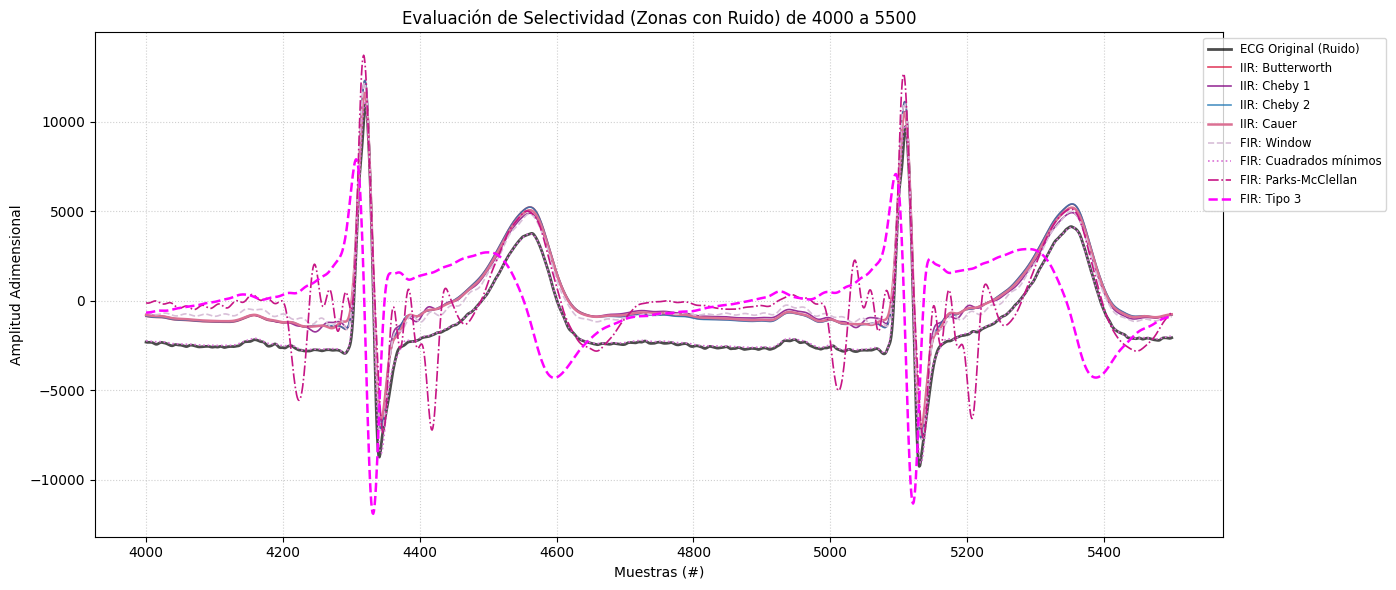

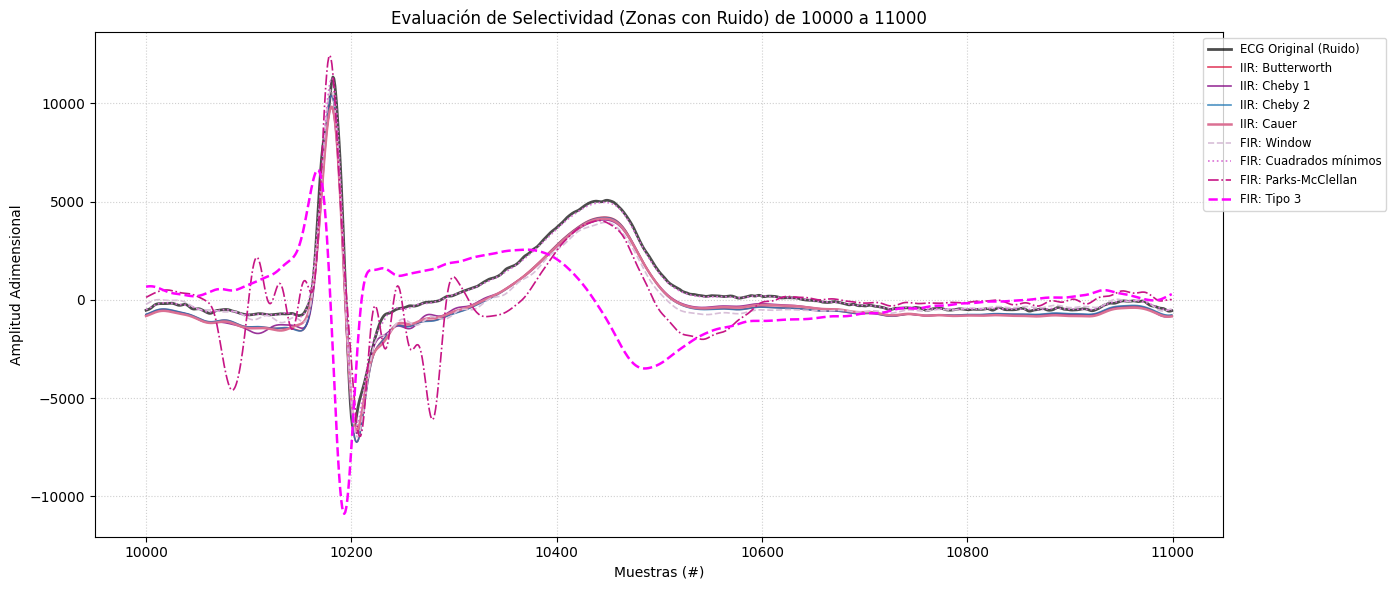

In [117]:
regs_interes_ruido = ([4000, 5500], [10e3, 11e3])

for ii in regs_interes_ruido:
    zoom_region = np.arange(np.max([0, int(ii[0])]), np.min([cant_muestras - max_demora, int(ii[1])]), dtype='uint')
    
    plt.figure(figsize=(14, 6))
    plt.plot(zoom_region, ecg_one_lead[zoom_region], label='ECG Original (Ruido)', color='black', alpha=0.7, linewidth=2)
    
    plt.plot(zoom_region, ecg_f_butt[zoom_region],   label='IIR: Butterworth', linewidth=1.2, color='crimson', alpha=0.8)
    plt.plot(zoom_region, ecg_f_cheby1[zoom_region], label='IIR: Cheby 1', linewidth=1.2, color='purple', alpha=0.8)
    plt.plot(zoom_region, ecg_f_cheby2[zoom_region], label='IIR: Cheby 2', linewidth=1.2, alpha=0.8)
    plt.plot(zoom_region, ecg_f_cauer[zoom_region],  label='IIR: Cauer', linewidth=1.8, color='palevioletred')
    
    plt.plot(zoom_region, ecg_f_win[zoom_region + demora_win],     label='FIR: Window', linewidth=1.2, color='thistle', linestyle='--')
    plt.plot(zoom_region, ecg_f_ls[zoom_region + demora_ls],       label='FIR: Cuadrados mínimos', linewidth=1.2, color='orchid', linestyle=':')
    plt.plot(zoom_region, ecg_f_rem[zoom_region + demora_rem],     label='FIR: Parks-McClellan', linewidth=1.2,color='mediumvioletred', linestyle='-.')
    plt.plot(zoom_region, ecg_f_tipo3[zoom_region + demora_tipo3], label='FIR: Tipo 3', linewidth=1.8, color='magenta', linestyle='--')
    
    plt.title('Evaluación de Selectividad (Zonas con Ruido) de ' + str(int(ii[0])) + ' a ' + str(int(ii[1])))
    plt.ylabel('Amplitud Adimensional')
    plt.xlabel('Muestras (#)')
    
    plt.legend(loc='upper right', bbox_to_anchor=(1.15, 1), fontsize='small')
    plt.grid(True, linestyle=':', alpha=0.6)
    plt.tight_layout()
    plt.show()

Se puede observar que los filtros IIR, tal como Cauer, Butterworth y Chebyshev son los que presentan un comportamiento óptimo en el seguimiento de la forma del compejo QRS original, manteniendo una "limpieza" en la oscilación de alta frecuencia que se ve en el ECG original. 

Como se utiliza "SOS" y "filtfilt" logran eliminar una fase que mantiene la onda R alineada en el tiempo, ya que hay retardo nulo. 

**Filtros IIR**

Se puede observar que el elíptico - Cauer - es el que plancha el ruido sin redondear tanto los picos agudos, por lo que parece ser el mejor filtro para detectar arritmias en zonas donde la morfología resulta importante. 

Cabe destacar que en el Spyder con el comando *%Matplotlib qt* resulta más sencillo de realizar esta comparación, puesto que es posible hacer zoom y observar mejor la adaptación de los diferentes tipos de filtros.

**Filtros FIR**

Estos filtros, a diferencia de los anteriores, poseen una transición más suave, se nota que no lograron "planchar" las interferencias de ruido de forma tan magnánime como el Cauer. Siguen la señal original de forma correcta. 

**Filtro tipo 3**

Resulta sumamente obvio que este representa el peor caso posible en comparación a los anteriores. Se encuentra desfasado y con una gran diferencia de amplitud, esto puede explicarse como característica intrínseca del tipo 3, puesto que actúa como un derivador y por lo tanto va calculando la pendiente de la señal, por lo que en lugar de mostrar el QRS muestra su velocidad de cambio. 

Se vuelve extremadamente inadecuado para el rocesamiento de un ECG ya que altera irreversiblemente la morfología del mismo. Por todo esto, cabe destacar que si se tuviera que elegir uno, así como se presentan, sin poder cambiarse sus parámetros, ya que quizás pese a desginar mucho tiempo en el toqueteo de las frecuencias, los taps y etc, puede no haberse llegao a una configuración óptima, parecería inteligente elegir el IIR Cauer debido a su eficiencia y capacidad para cumplir con la plantilla.

Los fltros FIR son útiles si se requiere una fase lineal perfecta, pero requieren de órdenes muchos más grandes, que a su vez no "rompan" el algoritmo. 

***Zona sin ruido***

Nuevamente se hace uso del código provisto en la Tarea Semanal 7.

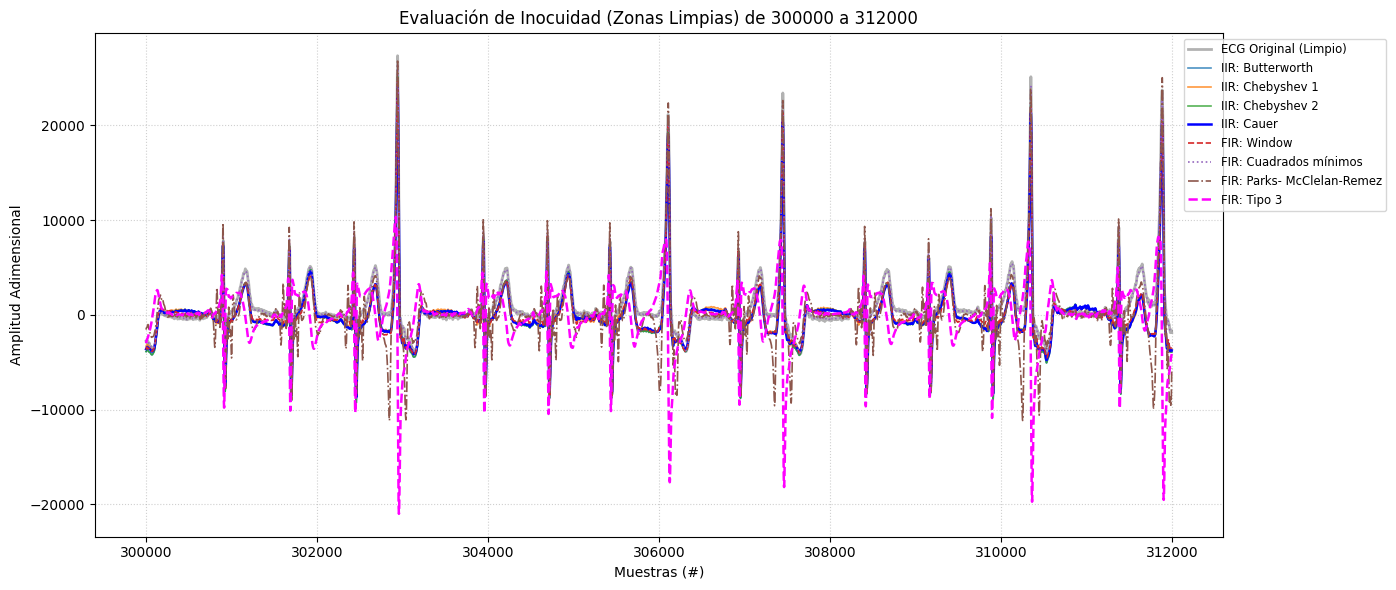

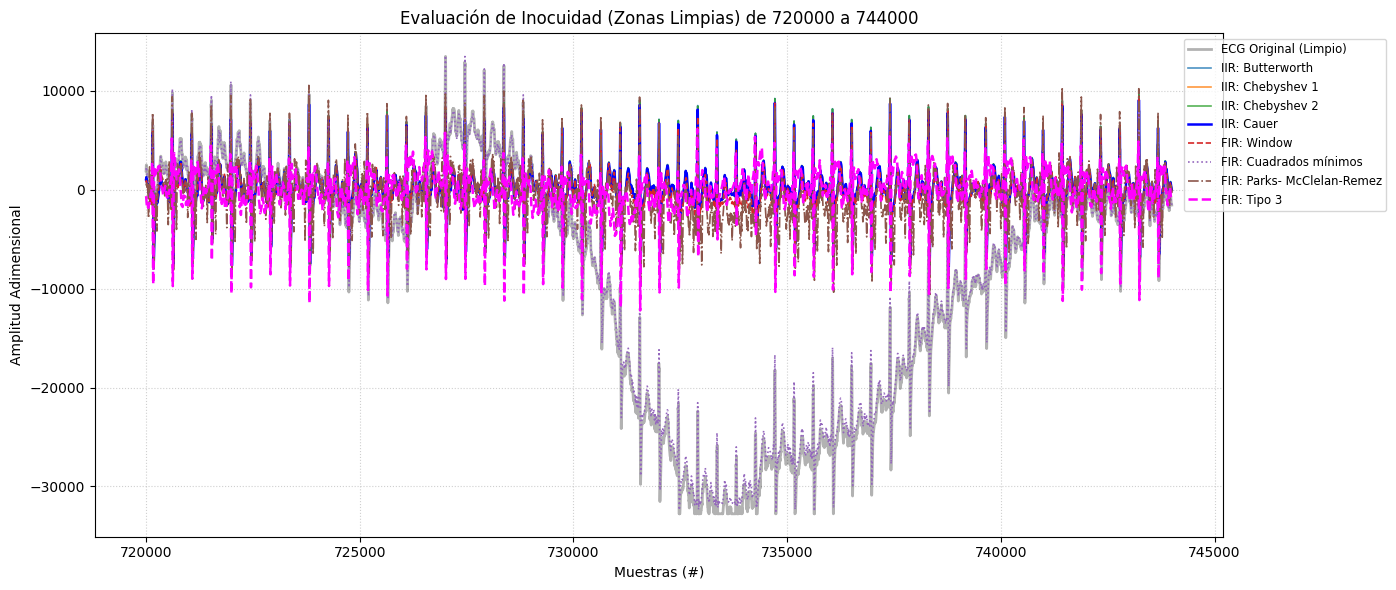

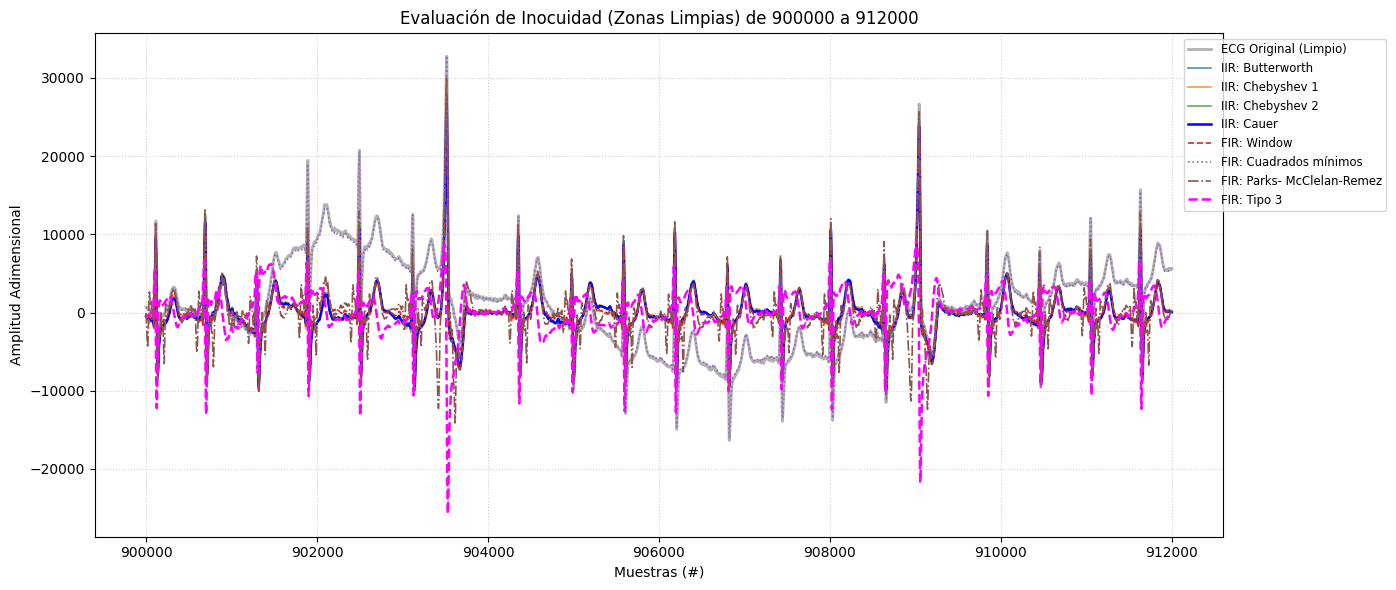

In [118]:
regs_interes_limpias = (
        np.array([5, 5.2]) * 60 * fs, 
        np.array([12, 12.4]) * 60 * fs, 
        np.array([15, 15.2]) * 60 * fs
)
for ii in regs_interes_limpias:
    zoom_region = np.arange(np.max([0, int(ii[0])]), np.min([cant_muestras - max_demora, int(ii[1])]), dtype='uint')
    
    plt.figure(figsize=(14, 6))
    plt.plot(zoom_region, ecg_one_lead[zoom_region], label='ECG Original (Limpio)', color='black', alpha=0.3, linewidth=2)
    
    plt.plot(zoom_region, ecg_f_butt[zoom_region],   label='IIR: Butterworth', linewidth=1.2, alpha=0.8)
    plt.plot(zoom_region, ecg_f_cheby1[zoom_region], label='IIR: Chebyshev 1', linewidth=1.2, alpha=0.8)
    plt.plot(zoom_region, ecg_f_cheby2[zoom_region], label='IIR: Chebyshev 2', linewidth=1.2, alpha=0.8)
    plt.plot(zoom_region, ecg_f_cauer[zoom_region],  label='IIR: Cauer', linewidth=1.8, color='blue')
    
    plt.plot(zoom_region, ecg_f_win[zoom_region + demora_win],     label='FIR: Window', linewidth=1.2, linestyle='--')
    plt.plot(zoom_region, ecg_f_ls[zoom_region + demora_ls],       label='FIR: Cuadrados mínimos', linewidth=1.2, linestyle=':')
    plt.plot(zoom_region, ecg_f_rem[zoom_region + demora_rem],     label='FIR: Parks- McClelan-Remez', linewidth=1.2, linestyle='-.')
    plt.plot(zoom_region, ecg_f_tipo3[zoom_region + demora_tipo3], label='FIR: Tipo 3', linewidth=1.8, color='magenta', linestyle='--')
    
    plt.title('Evaluación de Inocuidad (Zonas Limpias) de ' + str(int(ii[0])) + ' a ' + str(int(ii[1])))
    plt.ylabel('Amplitud Adimensional')
    plt.xlabel('Muestras (#)')
    
    plt.legend(loc='upper right', bbox_to_anchor=(1.15, 1), fontsize='small')
    plt.grid(True, linestyle=':', alpha=0.6)
    plt.tight_layout()
    plt.show()

En estas zonas "limpias" el filtro debería copiar la señal, pues no tiene nada que filtrar, esto sería lo esperado de manera ideal.
Se puede observar en el primer gráfico, una superposición casi perfecta entre la señal original del ECG y las salidas de los filtros, excluyendo por supuesto el de Tipo 3, que está completamente desfasado. La divergencia de amplitud de la onda R es prácticamente despreciable, debido a que este pico que resulta ser el más importante del ECG sale prácticamente igual a como entro, parecería que el filtro deja pasar las frecuencias sin atenuarlas ni fedormarlas. Esto habla de la fidelidad de la banda de paso.

En el segundo gráfico, se observa una divergencia entre los filtros y la señal, en la zona de "Wander de línea base" mencionada previamente en la itnroducción del presente trabajo, siendo el único filtro que copia también esa panza negativa el de Cuadrados mínimos. 

La divergencia del resto de los filtros no representa un fallo de los mismos, sino que pone en manifiesto su selectividad. Ya que logran atenuar efizcamente la componente baja, impidiendo que el ruido de linea base contamine la salida, centrando la señal en el eje isoeléctrico. 

Por su parte el FIR tipo 3, sigue desfasando y alterando la morfología de la señal, es prácticamente incompatible con la preservación de la sñeal y sus datos de relevancia clínica, independientemente de la zona posee o no ruido. 

**Verificación de si la respuesta en frecuencia cumple la plantilla**

Aclaración: En una de las clases virtuales el profesor nos pidió que le pidiéramos a "nuestra IA de confianza" que nos diagramara una plantilla para ver si cumplía o no el filtro, reutilicé esa que me dio la IA para aplicarla en esta parte.

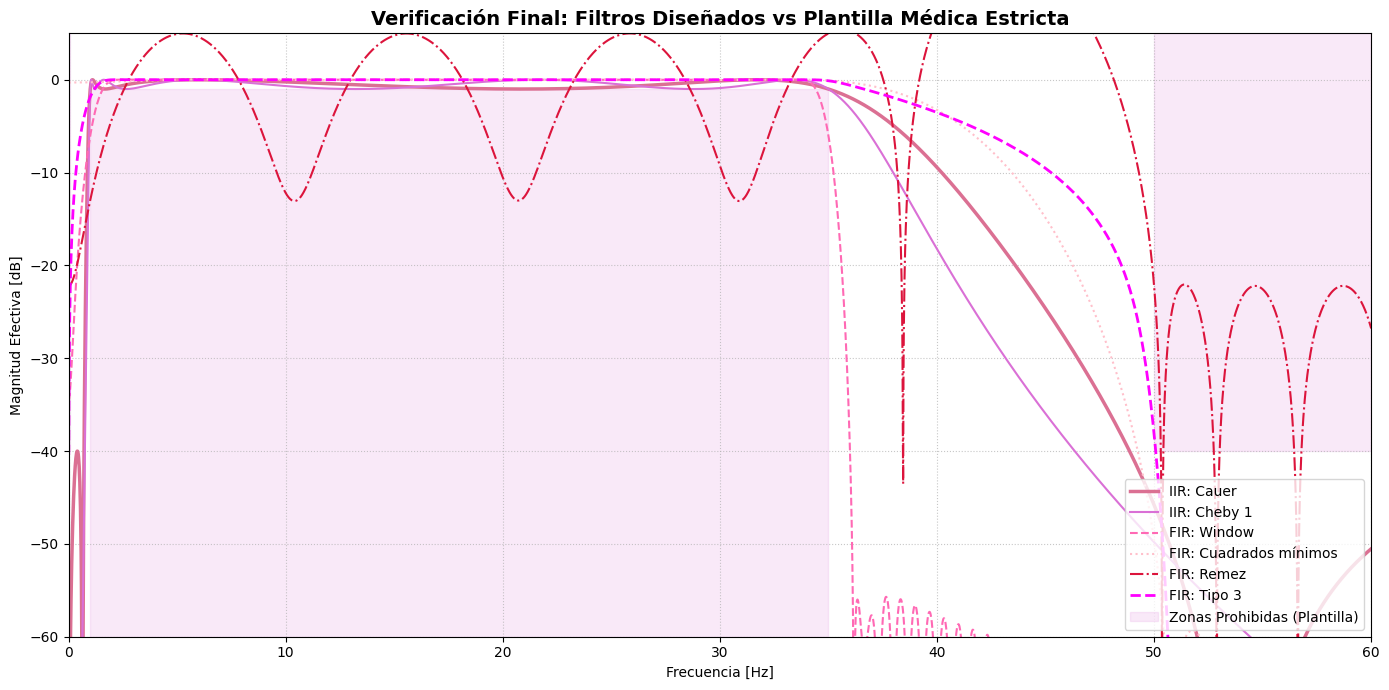

In [119]:
# Calculo la respuesta en frecuencia con mucha resolución en la zona de interés
frecuencias_hz = np.linspace(0.01, 60, 4000)

#Obtengo las respuestas de los IIR seleccionados
_, h_cauer  = sig.sosfreqz(sos_cauer, worN=frecuencias_hz, fs=fs)
_, h_cheby1 = sig.sosfreqz(sos_cheby1, worN=frecuencias_hz, fs=fs)

# Obtengo las respuestas complejas de los IIR
_, h_win   = sig.freqz(b_win, 1, worN=frecuencias_hz, fs=fs)
_, h_ls    = sig.freqz(b_ls, 1, worN=frecuencias_hz, fs=fs)
_, h_rem   = sig.freqz(b_rem, 1, worN=frecuencias_hz, fs=fs)
_, h_tipo3 = sig.freqz(b_tipo3, 1, worN=frecuencias_hz, fs=fs)

# 3. Convierto a Magnitud en dB
#  Como los IIR usan filtfilt , su transferencia se eleva al cuadrado 
# significa que en dB se multiplica por 2. Los FIR usan lfilter que es una pasada simple, no se multiplican.
mag_cauer  = 20 * np.log10(np.abs(h_cauer) + 1e-12) * 2 #Le agrego el 1w-12 para evitar el cartel de error. 
mag_cheby1 = 20 * np.log10(np.abs(h_cheby1) + 1e-12) * 2

mag_win   = 20 * np.log10(np.abs(h_win) + 1e-12)
mag_ls    = 20 * np.log10(np.abs(h_ls) + 1e-12)
mag_rem   = 20 * np.log10(np.abs(h_rem) + 1e-12)
mag_tipo3 = 20 * np.log10(np.abs(h_tipo3) + 1e-12)


plt.figure(figsize=(14, 7))

# Grafico los IIR
plt.plot(frecuencias_hz, mag_cauer,  label='IIR: Cauer', linewidth=2.5, color='palevioletred')
plt.plot(frecuencias_hz, mag_cheby1, label='IIR: Cheby 1', linewidth=1.5, color='orchid')

# Grafico los FIR
plt.plot(frecuencias_hz, mag_win,   label='FIR: Window', linewidth=1.5,color='hotpink', linestyle='--')
plt.plot(frecuencias_hz, mag_ls,    label='FIR: Cuadrados mínimos ', linewidth=1.5, color='pink', linestyle=':')
plt.plot(frecuencias_hz, mag_rem,   label='FIR: Remez', linewidth=1.5, color='crimson', linestyle='-.')
plt.plot(frecuencias_hz, mag_tipo3, label='FIR: Tipo 3', linewidth=2, color='magenta', linestyle='--')

plt.title('Verificación Final: Filtros Diseñados vs Plantilla Médica Estricta', fontsize=14, weight='bold')
plt.xlabel('Frecuencia [Hz]')
plt.ylabel('Magnitud Efectiva [dB]')

# Hago zoom en la zona de interés.
plt.xlim([0, 60]) 
plt.ylim([-60, 5]) # Acá dejo margen para ver el piso de atenuación

# --- DIBUJO LAS ZONAS PROHIBIDAS DE LA PLANTILLA ---

#  Banda de parada inferior - De 0 Hz a ws1=0.05Hz- No debe superar -40dB
plt.fill_between([0, ws1], -atenuacion, 5, color='orchid', alpha=0.15, label='Zonas Prohibidas (Plantilla)')

# Banda de paso -De wp1=1Hz a wp2=35Hz-, No debe caer por debajo de -1.0dB
plt.fill_between([wp1, wp2], -60, -ripple, color='orchid', alpha=0.15)

# Banda de parada superior - De ws2=50Hz en adelante- , No debe superar -40dB
plt.fill_between([ws2, 60], -atenuacion, 5, color='orchid', alpha=0.15)

plt.grid(True, which="both", linestyle=":", alpha=0.7)
plt.legend(loc='lower right')
plt.tight_layout()
plt.show()

Finalmente se puede observar que los filtros IIR, Cauer y Chebyshev se mantienen dentro de la zona blanca, lo que demuestra que la arquitectura del IIR es la opción más eficiente, pues logra la selectividad necesaria con un orden bajo.

El FIR Remez se escapa hacia arriba, invadiendo la zona rosadita, esto tiene que ver con que su ripple es elevado, al relajar los parámetros en la proxie se sacrificó la atenuación fuera de la banda.

A su vez, el filtro FIR tipo 3 demuestra que su diseño efectivamente no corresponde al de un pasa-banda, sino que es un derivativo. 

Por último, la comparativa de filtros revela que no existe una solución única, sino que nuevamente resulta fundamental el "trade-off" logrando un equilibrio entre la selectividad, estabilidad y preservación morfológica. Quizá si se hubiera dispuesto de aún más tiempo, se podría haber llegado a mejores resultados para los distintos tipos de filtros, sin embargo queda demostrado que el filtro IIR Cauer se consolida como la opción óptima de ECG, dado este caso y estos parámetros.  

**Bonus**

Proponga algún tipo de señal, ya sea de la TS anterior u otra que no haya sido analizada y repita el análisis. No olvide explicar su origen y cómo fue digitalizada.

ACLARACIÓN: La señal es la misma que la utilizada en la TS5, por lo tanto la forma de obtenerla es exactamente igual, a continuación adjunto la explicación anterior.

En primer lugar, elegí una señal, en este caso el ruido del violín de la introducción del Lago de los Cisnes de Tchaikovski (https://www.youtube.com/watch?v=cwTctSxuTIs), porque es mi musical favorito y quería ver cómo se vería el espectro de esa parte, en realidad quería probar con la segunda parte donde suena mucho más grave para ver si varíaban las frecuencias al compararlos, pero me quedé con solo la primer parte para no hacer el trabajo muy largo.

Luego me pirateé el video de youtube descargándomelo y lo recorté con un programa que tenía en la compu, después como lo tenía en un formatgo raro de M4A, tuve que subirlo a una página (https://cloudconvert.com/m4a-to-wav) para que me lo pasara a .wav, que es el que el profesor nos enseñó.

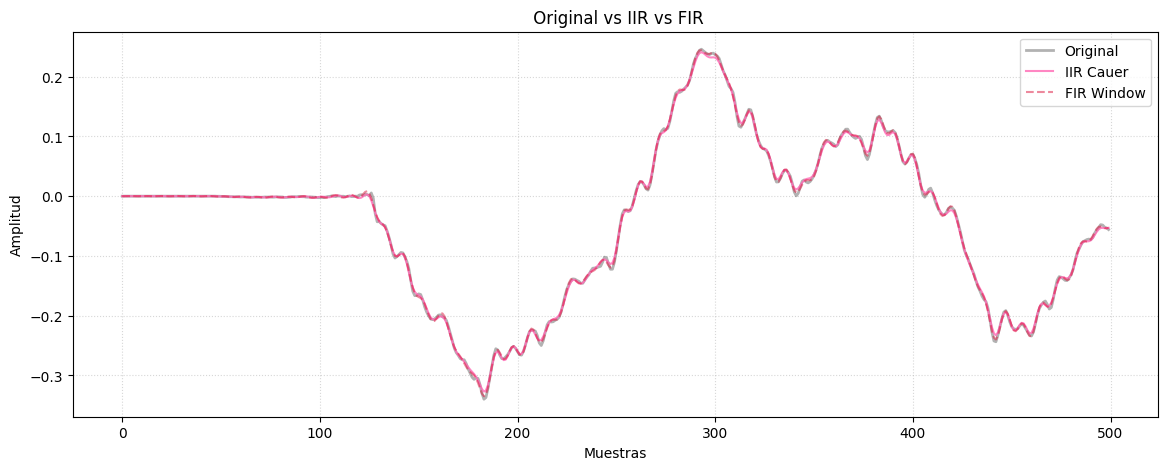

In [136]:
import numpy as np
import scipy.io.wavfile as wavfile
import scipy.signal as sig
import matplotlib.pyplot as plt
fs_bonus, datos_bonus = wavfile.read('audio_bonus.wav')

if datos_bonus.dtype == np.int16:
    audio_bonus_raw = datos_bonus / 32768.0
elif datos_bonus.dtype == np.int8:
    audio_bonus_raw = (datos_bonus / 128.0) - 1.0
else:
    audio_bonus_raw = datos_bonus

if len(audio_bonus_raw.shape) > 1:
    audio_bonus = audio_bonus_raw[:, 0]
else:
    audio_bonus = audio_bonus_raw

wp = 0.25 #Lo pongo a un cuarto de Nyq
ws = 0.35 

sos_cauer = sig.iirdesign(wp, ws, 1, 40, output='sos')
orden_fir = 501
b_win = sig.firwin(orden_fir, wp)


audio_f_cauer = sig.sosfiltfilt(sos_cauer, audio_bonus)
audio_f_win = sig.lfilter(b_win, 1.0, audio_bonus)

# lA IA me lo solucionó con esto, para eliminar el transitorio del FIR (orden_fir // 2)
transitorio = orden_fir // 2
plt.figure(figsize=(14, 5))
# Zoom en una zona con mucha actividad.
z_inicio = 400
z_fin = 900

# Ploteo el original u eld e Cauer IIR
plt.plot(audio_bonus[z_inicio:z_fin], label='Original', color='black', alpha=0.3, linewidth=2)
plt.plot(audio_f_cauer[z_inicio:z_fin], label='IIR Cauer', color='hotpink', alpha=0.8)

# Ploteo el FIR compensando el retardo para que se vea alineado.
# Se resta el transitorio al índice para que la onda caiga encima
plt.plot(np.arange(len(audio_f_win[z_inicio+transitorio:z_fin+transitorio])), 
         audio_f_win[z_inicio+transitorio:z_fin+transitorio], 
         label='FIR Window', linestyle='--', color='crimson',alpha=0.5)

plt.title(' Original vs IIR vs FIR')
plt.xlabel('Muestras')
plt.ylabel('Amplitud')
plt.legend()
plt.grid(True, linestyle=':', alpha=0.5)
plt.show()

Nota de la autora - yo- : Estuve muuucho tiempo tratando de solucionar esto, como ya sabrás por mis mensajes de Telegram, terminé teniendo que pedirle a la IA que me corrija las demoras y con eso logré alinearlos, lo cual me sirvió muchísimo para terminar de fijar ese concepto que no me había quedado del todo claro y con el cual ya había tenido problemas en esta TS. 

La implementación del filtro IIR mediante filtrado bidireccional,  permitió alcanzar una fase cero, eliminando cualquier retardo temporal, de esta forma se percibe el filtro alineado a la señal desde un principio. 
Por otro lado, fue necesario realizar una compensación  al filtro FIR —basada en su retardo de grupo constante, lo que demostró que es posible lograr una reconstrucción temporal idéntica a la original aprovechando la linealidad de fase del diseño FIR.

El filtro Cauer se destaca por su alta selectividad  con un orden  significativamente menor que el FIR, loq ue resulta crítico en aplicaciones donde los recursos de procesamiento son limitados, mientras que la estructura FIR es preferible cuando se dese estrictamente una fase lineal. 

La superposición observada en los gráficos temporales confirma que el diseño basado en el análisis espectral previo de la TS5, mediante el método Welch fue exitoso.